# Final Project · Wind Turbine Fault Detection

This notebook consolidates the project into a single, submission-ready workflow that runs from raw data validation through preprocessing, exploratory analysis, modeling, evaluation, and artifact generation.

## Notebook goals
- Show the **full data analysis pipeline** in one place for submission.
- Reuse the modular `wtfd` package instead of duplicating implementation details.
- Add **artifact guards** so repeated notebook execution does not unnecessarily rerun expensive preprocessing or modeling steps.
- Preserve the real project structure while still satisfying the course requirement for a single notebook.

## Project framing
This is a **time series predictive maintenance** problem using wind turbine SCADA data. The objective is to predict whether a turbine is approaching a fault event within a given lead window. The preprocessing pipeline creates canonical event-state labels, and the modeling workflow compares three operational prediction horizons:

- **pre_24h**
- **pre_48h**
- **pre_72h**

The notebook keeps the real-world modular architecture intact, but presents the work in a linear, well-documented form appropriate for course submission.


## How this notebook is organized

1. Set up the environment and resolve project paths  
2. Validate the repository structure and required inputs  
3. Reuse existing processed artifacts when possible, or run preprocessing if needed  
4. Inspect the processed dataset and create core visual diagnostics  
5. Run or reuse modeling experiments for the 24h, 48h, and 72h horizons  
6. Compare model performance across horizons  
7. Visualize feature importance and threshold behavior for the strongest result  
8. Summarize conclusions and reproducibility notes

> **Important:** This notebook is intentionally defensive. Expensive steps check for existing outputs before rebuilding them.


In [1]:
# Optional notebook convenience magics.
# These can be commented out if your environment does not support IPython magics.
%load_ext autoreload
%autoreload 2


In [2]:
from __future__ import annotations

import gc
import json
import sys
from pathlib import Path
from typing import Any, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import seaborn as sns
from IPython.display import Markdown, display


In [3]:
def find_project_root(start: Optional[Path] = None) -> Path:
    """Walk upward until a repository root is found."""
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root. Run this notebook from within the ML_Project repository."
    )

PROJECT_ROOT = find_project_root()
SRC_ROOT = PROJECT_ROOT / "src"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Source root:  {SRC_ROOT}")


Project root: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project
Source root:  /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/src


In [4]:
# Optional editable install for environments where the package has not been installed yet.
# Set to True only if imports fail below and you want the notebook to install the local package.
ENABLE_EDITABLE_INSTALL_IF_NEEDED = False

if ENABLE_EDITABLE_INSTALL_IF_NEEDED:
    import subprocess
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-e", str(PROJECT_ROOT)],
        check=True,
    )


In [6]:
from wtfd.data.preprocessing import WindFarmProcessor
from wtfd.models.artifacts import (
    ensure_run_output_dir,
    load_dataframe_artifact,
    load_json_artifact,
    save_dataframe_artifact,
    save_feature_importance,
    save_model_metrics,
    save_run_metadata,
    save_threshold_sweep,
)
from wtfd.models.experiments import get_experiment_config, list_available_experiments
from wtfd.models.feature_selector import (
    build_feature_matrix,
    summarize_feature_selection,
    validate_no_leakage_columns_in_features,
)
from wtfd.models.metrics import build_threshold_sweep_table
from wtfd.models.model_registry import get_model_config, list_available_models
from wtfd.models.splitter import WindFarmSplitter
from wtfd.models.trainer import WindFaultTrainer
from wtfd.utils.logging_utils import get_logger

logger = get_logger("wtfd.notebooks.final_project")

try:
    import xgboost  # noqa: F401
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

print("Available experiments:", list_available_experiments())
print("Available models:", list_available_models())
print("XGBoost available:", HAS_XGBOOST)


Available experiments: ['pre_24h', 'pre_48h', 'pre_72h']
Available models: ['logistic', 'rf', 'xgboost']
XGBoost available: True


## Notebook controls

The next cell contains the main notebook toggles. These are separated from the execution logic so the notebook remains easy to rerun during testing.

Recommended default behavior for submission:
- **reuse existing processed artifacts**
- **reuse existing modeling artifacts when available**
- **save fresh modeling outputs only when needed**


In [7]:
# ------------------------------------------------------------------
# Project paths
# ------------------------------------------------------------------
CONFIG_PATH = PROJECT_ROOT / "config" / "feature_map.yaml"
RAW_DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "zenodo_windfarm_data"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MASTER_DATASET_PATH = PROCESSED_DIR / "master_dataset.parquet"
ARTIFACT_ROOT = PROJECT_ROOT / "artifacts" / "modeling"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
TIMELINE_DIR = OUTPUT_DIR / "failure_timelines"

# ------------------------------------------------------------------
# Preprocessing controls
# ------------------------------------------------------------------
BUFFER_BEFORE_HOURS = 0.0
BUFFER_AFTER_HOURS = 0.0
REBUILD_EVENT_PARQUETS = False
REBUILD_MASTER_DATASET = False

# ------------------------------------------------------------------
# Data inspection controls
# ------------------------------------------------------------------
SAMPLE_N_ROWS = 5000
TOP_N_MISSING_FEATURES = 20

# ------------------------------------------------------------------
# Modeling controls
# ------------------------------------------------------------------
EXPERIMENT_NAMES = ["pre_24h", "pre_48h", "pre_72h"]
MODEL_NAMES_OVERRIDE = None     # e.g. ["logistic", "rf", "xgboost"]
NUMERIC_ONLY = True
FEATURE_SUBSET = None
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15
RANDOM_STATE = 42
REUSE_SAVED_MODEL_ARTIFACTS = True
SAVE_FRESH_MODELING_ARTIFACTS = False

# ------------------------------------------------------------------
# Visualization controls
# ------------------------------------------------------------------
TIMELINE_SIGNALS = [
    "vibration_raw",
    "nacelle_temp",
    "temp_delta_gearbox",
]
TIMELINE_HOURS_BEFORE = 168
TIMELINE_HOURS_AFTER = 24
TOP_N_FEATURES = 20


## Validate required repository inputs

This step confirms that the repository layout matches the expected project structure. It also reports whether processed artifacts already exist, which determines whether the notebook can skip expensive preprocessing steps.


In [8]:
required_paths = {
    "config": CONFIG_PATH,
    "raw_data_root": RAW_DATA_ROOT,
    "processed_dir": PROCESSED_DIR,
    "artifact_root": ARTIFACT_ROOT,
    "output_dir": OUTPUT_DIR,
}

for path_name, path_value in required_paths.items():
    print(f"{path_name:>16}: {path_value} | exists={path_value.exists()}")

assert CONFIG_PATH.exists(), f"Missing config file: {CONFIG_PATH}"
assert RAW_DATA_ROOT.exists(), f"Missing raw data root: {RAW_DATA_ROOT}"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TIMELINE_DIR.mkdir(parents=True, exist_ok=True)

event_parquet_files = sorted(
    [p for p in PROCESSED_DIR.glob("*.parquet") if p.name != "master_dataset.parquet"]
)

repo_summary_df = pd.DataFrame(
    [
        {"item": "event parquet files", "count": len(event_parquet_files)},
        {"item": "master dataset exists", "count": int(MASTER_DATASET_PATH.exists())},
        {"item": "artifact experiment folders", "count": sum(1 for p in ARTIFACT_ROOT.glob("*") if p.is_dir())},
    ]
)
display(repo_summary_df)


          config: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/config/feature_map.yaml | exists=True
   raw_data_root: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/data/raw/zenodo_windfarm_data | exists=True
   processed_dir: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/data/processed | exists=True
   artifact_root: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifacts/modeling | exists=True
      output_dir: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/outputs | exists=True


,item,count
0,event parquet files,95
1,master dataset exists,1
2,artifact experiment folders,3


## Methodology summary

### Data processing strategy
The preprocessing pipeline standardizes farm-specific SCADA inputs into a consistent schema, normalizes units, creates derived features, and assigns canonical event-state labels. This design keeps the processed dataset flexible enough to support multiple prediction windows without rerunning the full preprocessing pipeline each time.

### Modeling strategy
Three experiments are evaluated: **24-hour**, **48-hour**, and **72-hour** lead windows. Each experiment uses the same processed base table but redefines the positive class according to the canonical state labels. This makes the comparison between horizons fair and reproducible.

### Algorithms
The notebook compares three models already registered in the project:
- **Logistic Regression** for a simple, interpretable baseline
- **Random Forest** for a non-linear tree-based baseline
- **XGBoost** for a stronger gradient boosting candidate when available

### Split strategy
The default split is **event-level chronological splitting**, which keeps whole events in the same split while preserving temporal order. That reduces leakage and better reflects real deployment conditions.


## Initialize the preprocessing pipeline

The processor reads the YAML feature map, standardizes raw inputs, engineers derived features, and produces event-level Parquet files plus the consolidated master dataset.


In [9]:
processor = WindFarmProcessor(
    config_path=CONFIG_PATH,
    buffer_before_hours=BUFFER_BEFORE_HOURS,
    buffer_after_hours=BUFFER_AFTER_HOURS,
)

processor


2026-04-14 12:48:13 | INFO | wtfd.data.preprocessing | Initialized WindFarmProcessor with config_path=/mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/config/feature_map.yaml, buffer_before_hours=0.0, buffer_after_hours=0.0


## Run preprocessing only when needed

The notebook reuses existing outputs unless the rebuild flags are enabled. This keeps iterative notebook testing practical while still preserving the full data processing logic required by the assignment.


In [10]:
if REBUILD_EVENT_PARQUETS or not event_parquet_files:
    logger.info("Running event-level preprocessing.")
    processor.process_all_turbines(
        raw_data_root=RAW_DATA_ROOT,
        output_dir=PROCESSED_DIR,
    )
    event_parquet_files = sorted(
        [p for p in PROCESSED_DIR.glob("*.parquet") if p.name != "master_dataset.parquet"]
    )
else:
    logger.info("Reusing existing event-level parquet files.")
    print(f"Reusing {len(event_parquet_files)} event-level parquet files from {PROCESSED_DIR}")

if REBUILD_MASTER_DATASET or not MASTER_DATASET_PATH.exists():
    if not event_parquet_files:
        raise FileNotFoundError(
            "No event-level parquet files are available, so the master dataset cannot be built."
        )
    logger.info("Building consolidated master dataset.")
    master_dataset_output = processor.create_master_dataset(
        processed_dir=PROCESSED_DIR,
        output_path=MASTER_DATASET_PATH,
    )
    print(f"Master dataset created: {master_dataset_output}")
else:
    logger.info("Reusing existing master dataset.")
    print(f"Reusing existing master dataset: {MASTER_DATASET_PATH}")

assert MASTER_DATASET_PATH.exists(), f"Master dataset not found: {MASTER_DATASET_PATH}"


2026-04-14 12:48:13 | INFO | wtfd.notebooks.final_project | Reusing existing event-level parquet files.
2026-04-14 12:48:13 | INFO | wtfd.notebooks.final_project | Reusing existing master dataset.


Reusing 95 event-level parquet files from /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/data/processed
Reusing existing master dataset: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/data/processed/master_dataset.parquet


## Review generated preprocessing artifacts

The event-level Parquet files preserve event granularity, while the master dataset supports modeling and consolidated inspection. The next cells summarize what was produced and inspect the schema without loading the entire dataset into memory.


In [11]:
event_file_summary = pd.DataFrame(
    {
        "file_name": [p.name for p in event_parquet_files],
        "size_mb": [round(p.stat().st_size / (1024 ** 2), 3) for p in event_parquet_files],
    }
).sort_values("file_name").reset_index(drop=True)

display(event_file_summary.head(10))

master_parquet = pq.ParquetFile(MASTER_DATASET_PATH)
print(f"Master dataset row groups: {master_parquet.num_row_groups}")
print("Master dataset schema:")
print(master_parquet.schema)


,file_name,size_mb
0,A_event_0.parquet,7.362
1,A_event_10.parquet,7.208
2,A_event_13.parquet,7.201
3,A_event_14.parquet,7.330
4,A_event_17.parquet,7.416
5,A_event_22.parquet,7.061
6,A_event_24.parquet,7.407
7,A_event_25.parquet,7.373
8,A_event_26.parquet,7.203
9,A_event_3.parquet,7.455


Master dataset row groups: 96
Master dataset schema:
required group field_id=-1 schema {
  optional int64 field_id=-1 time_stamp (Timestamp(isAdjustedToUTC=false, timeUnit=nanoseconds, is_from_converted_type=false, force_set_converted_type=false));
  optional binary field_id=-1 farm_id (String);
  optional binary field_id=-1 asset_id (String);
  optional double field_id=-1 amb_temp;
  optional double field_id=-1 wind_speed;
  optional double field_id=-1 pitch_angle;
  optional double field_id=-1 active_power;
  optional double field_id=-1 gen_speed;
  optional double field_id=-1 gearbox_oil_temp;
  optional double field_id=-1 transformer_temp;
  optional double field_id=-1 nacelle_temp;
  optional double field_id=-1 hub_temp;
  optional double field_id=-1 yaw_error;
  optional double field_id=-1 vibration_raw;
  optional double field_id=-1 hydraulic_temp;
  optional double field_id=-1 generator_temp;
  optional double field_id=-1 temp_delta_gearbox;
  optional double field_id=-1 temp_t

## Load a small sample for exploratory inspection

A small sample is used for fast diagnostics. This keeps the notebook responsive while still allowing us to validate labels, feature availability, and data quality before modeling.


In [12]:
sample_batches = []
rows_loaded = 0

for batch in master_parquet.iter_batches(batch_size=SAMPLE_N_ROWS):
    sample_batches.append(batch)
    rows_loaded += batch.num_rows
    if rows_loaded >= SAMPLE_N_ROWS:
        break

sample_df = pa.Table.from_batches(sample_batches).slice(0, SAMPLE_N_ROWS).to_pandas()

print(f"Loaded {len(sample_df):,} sample rows from {MASTER_DATASET_PATH.name}")
display(sample_df.head())
print()
sample_df.info()


Loaded 5,000 sample rows from master_dataset.parquet


,time_stamp,farm_id,asset_id,amb_temp,wind_speed,pitch_angle,active_power,gen_speed,gearbox_oil_temp,transformer_temp,nacelle_temp,hub_temp,yaw_error,vibration_raw,hydraulic_temp,generator_temp,temp_delta_gearbox,temp_trend_24h,rpm_volatility,temp_divergence,power_efficiency,vibration_magnitude,gearbox_oil_temp_delta_6,gearbox_oil_temp_volatility_6,gearbox_oil_temp_delta_24,gearbox_oil_temp_volatility_24,generator_temp_delta_6,generator_temp_volatility_6,generator_temp_delta_24,generator_temp_volatility_24,active_power_delta_6,active_power_volatility_6,active_power_delta_24,active_power_volatility_24,yaw_error_delta_6,yaw_error_volatility_6,yaw_error_delta_24,yaw_error_volatility_24,event_id,event_label,event_start,event_end,state_label,state_name,is_excluded_buffer,target
0,2022-08-04 06:10:00,A,0,22.0,1.7,24.0,-2.560,35.3,41.0,66.333333,30.0,31.0,129.4,22.1,41.0,31.5,19.0,0.0,0.0,-1.0,-0.521067,22.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0.0
1,2022-08-04 06:20:00,A,0,22.0,1.7,24.0,-2.556,0.0,41.0,66.333333,30.0,31.0,133.6,0.0,41.0,31.5,19.0,0.0,0.0,-1.0,-0.520252,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0.0
2,2022-08-04 06:30:00,A,0,22.0,0.9,24.0,-2.712,2.8,41.0,66.333333,30.0,31.0,167.1,5.8,41.0,31.5,19.0,0.0,0.0,-1.0,-3.720165,5.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0.0
3,2022-08-04 06:40:00,A,0,22.0,1.5,24.0,-2.548,0.4,41.0,66.000000,29.0,30.0,-49.1,1.9,41.0,31.5,19.0,0.0,0.0,-1.0,-0.754963,1.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0.0
4,2022-08-04 06:50:00,A,0,22.0,1.0,24.0,-2.568,0.0,41.0,65.666667,29.0,30.0,-107.3,0.0,41.0,30.5,19.0,0.0,0.0,-1.0,-2.568000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0.0



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 46 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   time_stamp                      5000 non-null   datetime64[ns]
 1   farm_id                         5000 non-null   object        
 2   asset_id                        5000 non-null   object        
 3   amb_temp                        5000 non-null   float64       
 4   wind_speed                      5000 non-null   float64       
 5   pitch_angle                     5000 non-null   float64       
 6   active_power                    5000 non-null   float64       
 7   gen_speed                       5000 non-null   float64       
 8   gearbox_oil_temp                5000 non-null   float64       
 9   transformer_temp                5000 non-null   float64       
 10  nacelle_temp                    5000 non-null   float64       
 11  hub

## Basic sample sanity checks

These checks verify that the processed sample includes the canonical labeling fields and a reasonable set of engineered features.


In [13]:
required_label_columns = ["state_label", "state_name", "target"]
present_label_columns = [c for c in required_label_columns if c in sample_df.columns]

print("Present label columns:", present_label_columns)

expected_features = set(processor.standard_features) | set(processor.config.get("derived_features", []))
present_expected_features = sorted(expected_features & set(sample_df.columns))
missing_expected_features = sorted(expected_features - set(sample_df.columns))

schema_check_df = pd.DataFrame(
    [
        {
            "n_sample_rows": len(sample_df),
            "n_columns": sample_df.shape[1],
            "n_present_expected_features": len(present_expected_features),
            "n_missing_expected_features": len(missing_expected_features),
        }
    ]
)
display(schema_check_df)

if missing_expected_features:
    print("Missing expected features:")
    print(missing_expected_features[:50])
else:
    print("All expected mapped/derived features are present in the sample.")


Present label columns: ['state_label', 'state_name', 'target']


,n_sample_rows,n_columns,n_present_expected_features,n_missing_expected_features
0,5000,46,19,0


All expected mapped/derived features are present in the sample.


## Visualization 1 · Canonical state distribution

This plot shows how the canonical event-state labels are distributed in the processed sample. It helps confirm that the preprocessing stage created the time-to-event states needed for the downstream horizon experiments.


,state_name,count
0,normal,5000


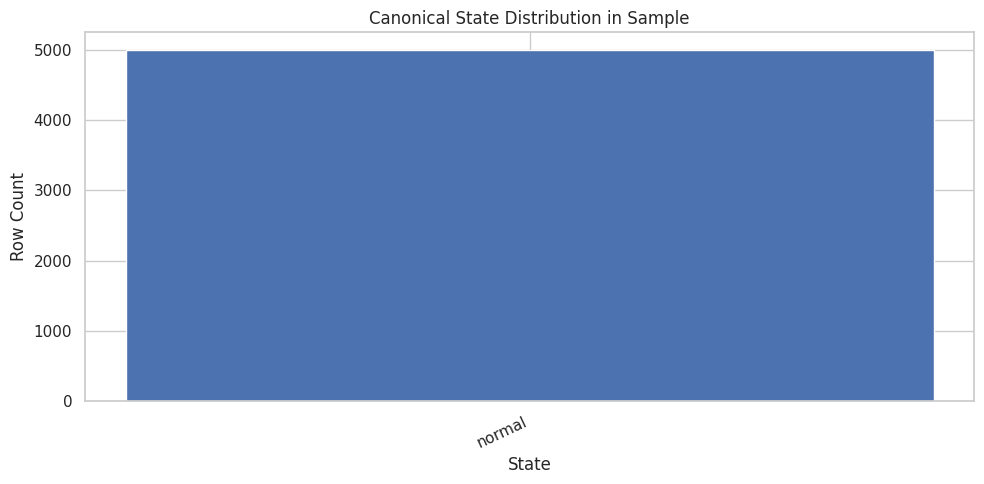

In [14]:
if "state_name" in sample_df.columns:
    state_counts = (
        sample_df["state_name"]
        .astype(str)
        .value_counts()
        .rename_axis("state_name")
        .reset_index(name="count")
    )
    display(state_counts)

    plt.figure(figsize=(10, 5))
    plt.bar(state_counts["state_name"], state_counts["count"])
    plt.title("Canonical State Distribution in Sample")
    plt.xlabel("State")
    plt.ylabel("Row Count")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("The sample does not contain 'state_name', so this plot was skipped.")


## Visualization 2 · Feature missingness in the processed sample

Missingness is summarized after preprocessing so we can confirm whether the standardized feature space still contains sparse or partially available signals. This is especially important in operational SCADA data.


,column,missing_fraction
0,time_stamp,0.0
1,yaw_error_delta_6,0.0
2,gearbox_oil_temp_volatility_24,0.0
3,generator_temp_delta_6,0.0
4,generator_temp_volatility_6,0.0
5,generator_temp_delta_24,0.0
6,generator_temp_volatility_24,0.0
7,active_power_delta_6,0.0
8,active_power_volatility_6,0.0
9,active_power_delta_24,0.0


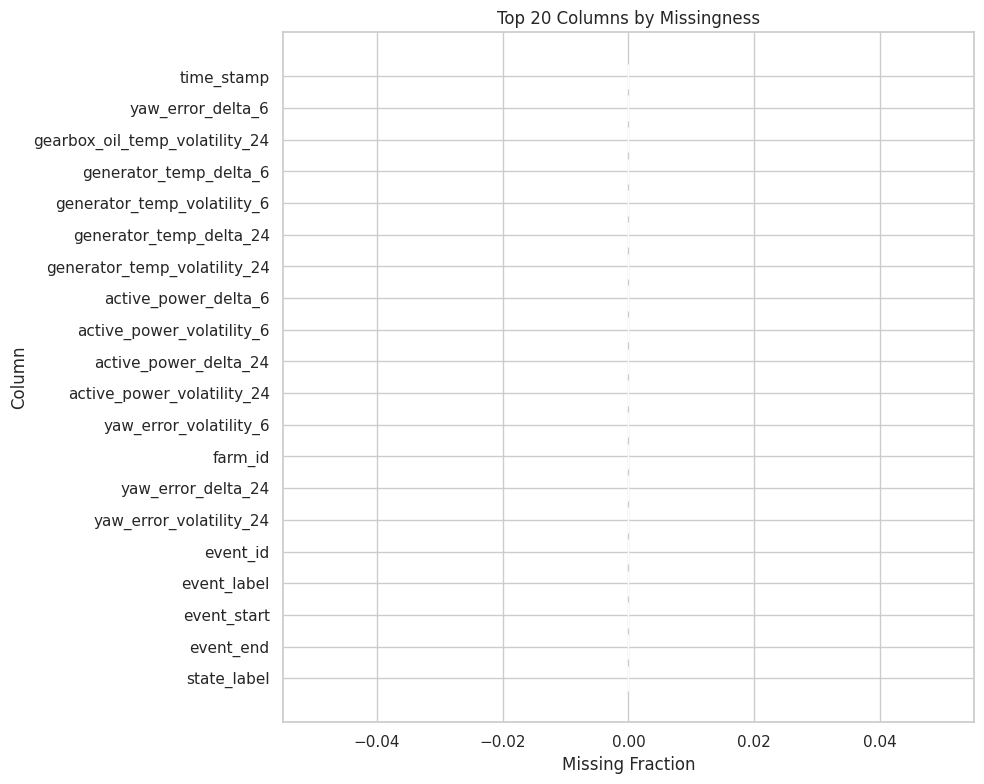

In [15]:
missingness_df = (
    sample_df.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_fraction")
    .reset_index()
    .rename(columns={"index": "column"})
)

display(missingness_df.head(TOP_N_MISSING_FEATURES))

plot_missingness_df = missingness_df.head(TOP_N_MISSING_FEATURES).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(plot_missingness_df["column"], plot_missingness_df["missing_fraction"])
plt.title(f"Top {TOP_N_MISSING_FEATURES} Columns by Missingness")
plt.xlabel("Missing Fraction")
plt.ylabel("Column")
plt.tight_layout()
plt.show()


## Visualization 3 · Example event timeline

A single event-level Parquet file is used to generate an interpretable failure timeline. The purpose is not to prove causality from one event, but to visually show how selected operational signals evolve around a fault event.


In [16]:
def make_failure_timeline_plot(
    df_all: pd.DataFrame,
    farm_id: Any,
    turbine_id: Any,
    event_id: Any,
    event_label: Any,
    event_start: pd.Timestamp,
    signal_cols: list[str],
    hours_before: int = 168,
    hours_after: int = 24,
) -> None:
    """Plot normalized trajectories for selected signals around an event start."""
    timestamp_col = "time_stamp"
    farm_col = "farm_id"
    turbine_col = "asset_id"

    df_turbine = df_all[
        (df_all[farm_col] == farm_id) &
        (df_all[turbine_col] == turbine_id)
    ].copy()

    if df_turbine.empty:
        print("No rows were found for the selected turbine.")
        return

    window_start = event_start - pd.Timedelta(hours=hours_before)
    window_end = event_start + pd.Timedelta(hours=hours_after)

    df_window = df_turbine[
        (df_turbine[timestamp_col] >= window_start) &
        (df_turbine[timestamp_col] <= window_end)
    ].copy()

    if df_window.empty:
        print("No rows were found inside the requested timeline window.")
        return

    df_window["hours_from_event_start"] = (
        (df_window[timestamp_col] - event_start).dt.total_seconds() / 3600.0
    )

    available_signals = [c for c in signal_cols if c in df_window.columns]
    if not available_signals:
        print("None of the requested timeline signals are present in this event file.")
        return

    normalized_cols = []
    for col in available_signals:
        series = pd.to_numeric(df_window[col], errors="coerce")
        std = series.std()
        out_col = f"{col}_z"
        if pd.isna(std) or std == 0:
            df_window[out_col] = 0.0
        else:
            df_window[out_col] = (series - series.mean()) / std
        normalized_cols.append(out_col)

    plt.figure(figsize=(10, 5.5))
    for original_col, norm_col in zip(available_signals, normalized_cols):
        plt.plot(
            df_window["hours_from_event_start"],
            df_window[norm_col],
            linewidth=2,
            label=original_col.replace("_", " ").title(),
        )

    plt.axvline(0, linestyle="--", linewidth=2, label="Event Start")
    plt.title(f"Example Failure Timeline | Farm {farm_id} | Turbine {turbine_id} | Event {event_id} ({event_label})")
    plt.xlabel("Hours Relative to Event Start")
    plt.ylabel("Normalized Sensor Value (z-score)")
    plt.xlim(-hours_before, hours_after)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()


,farm_id,asset_id,event_id,event_label,event_start
0,A,0,0,anomaly,2023-08-06 06:10:00


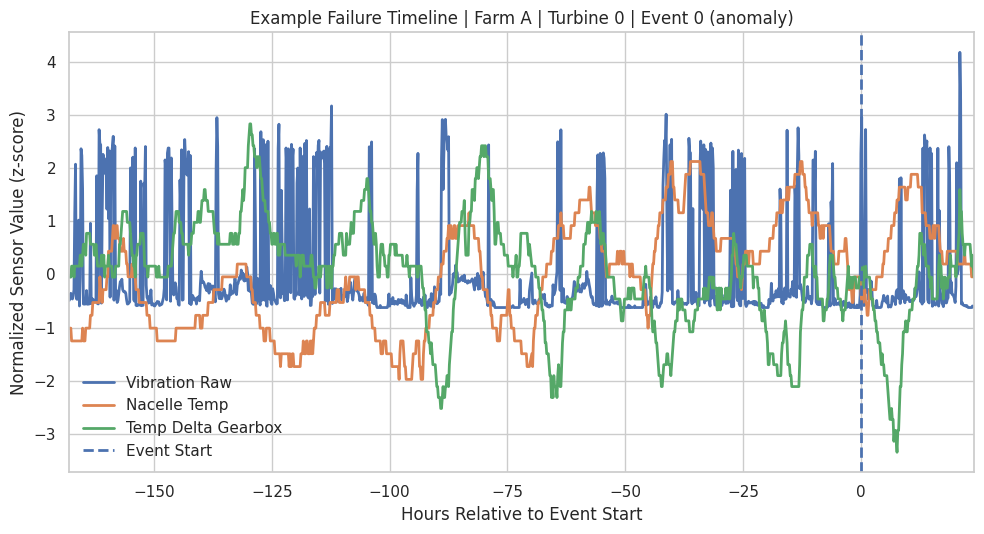

In [17]:
example_event_path = next((p for p in event_parquet_files if p.exists()), None)

if example_event_path is None:
    print("No event-level parquet file was available for the timeline example.")
else:
    example_event_df = pd.read_parquet(example_event_path).copy()

    for dt_col in ["time_stamp", "event_start", "event_end"]:
        if dt_col in example_event_df.columns:
            example_event_df[dt_col] = pd.to_datetime(example_event_df[dt_col], errors="coerce")

    event_cols = ["farm_id", "asset_id", "event_id", "event_label", "event_start"]
    event_index_df = (
        example_event_df[event_cols]
        .dropna(subset=["event_start"])
        .drop_duplicates()
        .sort_values(["farm_id", "asset_id", "event_start", "event_id"])
        .reset_index(drop=True)
    )

    if event_index_df.empty:
        print(f"No valid event rows were found in {example_event_path.name}")
    else:
        display(event_index_df.head())
        row = event_index_df.iloc[0]
        make_failure_timeline_plot(
            df_all=example_event_df,
            farm_id=row["farm_id"],
            turbine_id=row["asset_id"],
            event_id=row["event_id"],
            event_label=row["event_label"],
            event_start=row["event_start"],
            signal_cols=TIMELINE_SIGNALS,
            hours_before=TIMELINE_HOURS_BEFORE,
            hours_after=TIMELINE_HOURS_AFTER,
        )


## Load the full processed dataset for modeling

The model training section uses the consolidated master dataset. This is the canonical input to the experiment definitions.


In [18]:
master_df = pd.read_parquet(MASTER_DATASET_PATH)
print(f"Master dataset shape: {master_df.shape}")
display(master_df.head(3))


Master dataset shape: (5242948, 46)


,time_stamp,farm_id,asset_id,amb_temp,wind_speed,pitch_angle,active_power,gen_speed,gearbox_oil_temp,transformer_temp,nacelle_temp,hub_temp,yaw_error,vibration_raw,hydraulic_temp,generator_temp,temp_delta_gearbox,temp_trend_24h,rpm_volatility,temp_divergence,power_efficiency,vibration_magnitude,gearbox_oil_temp_delta_6,gearbox_oil_temp_volatility_6,gearbox_oil_temp_delta_24,gearbox_oil_temp_volatility_24,generator_temp_delta_6,generator_temp_volatility_6,generator_temp_delta_24,generator_temp_volatility_24,active_power_delta_6,active_power_volatility_6,active_power_delta_24,active_power_volatility_24,yaw_error_delta_6,yaw_error_volatility_6,yaw_error_delta_24,yaw_error_volatility_24,event_id,event_label,event_start,event_end,state_label,state_name,is_excluded_buffer,target
0,2022-08-04 06:10:00,A,0,22.0,1.7,24.0,-2.560,35.3,41.0,66.333333,30.0,31.0,129.4,22.1,41.0,31.5,19.0,0.0,0.0,-1.0,-0.521067,22.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0.0
1,2022-08-04 06:20:00,A,0,22.0,1.7,24.0,-2.556,0.0,41.0,66.333333,30.0,31.0,133.6,0.0,41.0,31.5,19.0,0.0,0.0,-1.0,-0.520252,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0.0
2,2022-08-04 06:30:00,A,0,22.0,0.9,24.0,-2.712,2.8,41.0,66.333333,30.0,31.0,167.1,5.8,41.0,31.5,19.0,0.0,0.0,-1.0,-3.720165,5.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0.0


## Modeling helpers

The following utilities either load the most recent saved experiment artifacts or execute the full experiment directly from the processed dataset. This is the key mechanism that keeps the notebook practical as a single-file submission.


In [19]:
def find_latest_run_dir(experiment_name: str, artifact_root: Path) -> Optional[Path]:
    """Return the newest saved artifact directory for an experiment, if one exists."""
    experiment_dir = artifact_root / experiment_name
    if not experiment_dir.exists():
        return None

    run_dirs = [p for p in experiment_dir.iterdir() if p.is_dir()]
    if not run_dirs:
        return None

    return max(run_dirs, key=lambda p: p.stat().st_mtime)


def load_saved_experiment_bundle(experiment_name: str, artifact_root: Path) -> Optional[dict[str, Any]]:
    """Load saved CSV/JSON artifacts for the newest experiment run if they exist."""
    run_dir = find_latest_run_dir(experiment_name, artifact_root)
    if run_dir is None:
        return None

    results_path = run_dir / "model_comparison_summary.csv"
    threshold_path = run_dir / "threshold_sweep.csv"
    importance_path = run_dir / "feature_importance.csv"
    metadata_path = run_dir / "run_metadata.json"
    summary_metrics_path = run_dir / "summary_metrics.json"

    core_paths = [results_path, threshold_path, importance_path, metadata_path, summary_metrics_path]
    if not all(path.exists() for path in core_paths):
        return None

    results_df = load_dataframe_artifact(results_path)
    threshold_df = load_dataframe_artifact(threshold_path)
    importance_df = load_dataframe_artifact(importance_path)
    run_metadata = load_json_artifact(metadata_path)
    summary_metrics = load_json_artifact(summary_metrics_path)

    best_model_name = summary_metrics.get("best_model_name")
    best_threshold = summary_metrics.get("best_threshold")

    best_row = None
    if "model_name" in results_df.columns and best_model_name in set(results_df["model_name"]):
        best_row = results_df.loc[results_df["model_name"] == best_model_name].iloc[0].to_dict()
    elif not results_df.empty:
        best_row = results_df.iloc[0].to_dict()

    return {
        "experiment_name": experiment_name,
        "source": "saved_artifact",
        "run_dir": run_dir,
        "results_df": results_df,
        "threshold_df": threshold_df,
        "importance_df": importance_df,
        "run_metadata": run_metadata,
        "summary_metrics": summary_metrics,
        "best_model_name": best_model_name,
        "best_threshold": best_threshold,
        "best_row": best_row,
        "train_df": None,
        "val_df": None,
        "test_df": None,
        "feature_summary": run_metadata.get("feature_selection"),
        "detailed_results": None,
    }


def build_experiment_dataset(df: pd.DataFrame, experiment_config: dict[str, Any]) -> pd.DataFrame:
    """Create the experiment-specific binary target and drop excluded-buffer rows."""
    df_exp = WindFarmSplitter.create_binary_target_from_state(
        df=df.copy(),
        positive_states=experiment_config["positive_states"],
    )
    df_exp = df_exp[df_exp["target"].notna()].copy()
    df_exp["target"] = df_exp["target"].astype(int)
    return df_exp


def split_experiment_dataset(
    modeling_df: pd.DataFrame,
    split_method: str,
    train_size: float = 0.70,
    val_size: float = 0.15,
    test_size: float = 0.15,
    random_state: int = 42,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Route to the appropriate splitter method."""
    splitter = WindFarmSplitter(random_state=random_state)

    if split_method in {"event_chronological", "event_level_time"}:
        return splitter.get_event_level_time_split(
            modeling_df,
            train_size=train_size,
            val_size=val_size,
            test_size=test_size,
        )
    if split_method in {"group_time", "grouped_time_by_turbine"}:
        return splitter.get_grouped_time_split_by_turbine(
            modeling_df,
            train_size=train_size,
            val_size=val_size,
            test_size=test_size,
        )
    if split_method in {"global_time", "chronological"}:
        return splitter.get_global_time_split(
            modeling_df,
            train_size=train_size,
            val_size=val_size,
            test_size=test_size,
        )

    raise ValueError(f"Unsupported split_method: {split_method}")


def run_experiment_fresh(
    master_df: pd.DataFrame,
    experiment_name: str,
    artifact_root: Path,
    model_names_override: Optional[list[str]] = None,
    numeric_only: bool = True,
    feature_subset: Optional[str] = None,
    train_size: float = 0.70,
    val_size: float = 0.15,
    test_size: float = 0.15,
    random_state: int = 42,
    save_outputs: bool = False,
) -> dict[str, Any]:
    """Run a modeling experiment from scratch using the reusable project modules."""
    experiment = get_experiment_config(experiment_name)
    modeling_df = build_experiment_dataset(master_df, experiment)

    train_df, val_df, test_df = split_experiment_dataset(
        modeling_df=modeling_df,
        split_method=experiment["split_method"],
        train_size=train_size,
        val_size=val_size,
        test_size=test_size,
        random_state=random_state,
    )

    feature_summary = summarize_feature_selection(
        train_df,
        numeric_only=numeric_only,
        feature_subset=feature_subset,
    )
    feature_names = feature_summary["selected_features"]
    validate_no_leakage_columns_in_features(feature_names)

    X_train = build_feature_matrix(train_df, numeric_only=numeric_only, feature_subset=feature_subset)
    y_train = train_df["target"].copy()

    X_val = build_feature_matrix(val_df, numeric_only=numeric_only, feature_subset=feature_subset)
    y_val = val_df["target"].copy()

    X_test = build_feature_matrix(test_df, numeric_only=numeric_only, feature_subset=feature_subset)
    y_test = test_df["target"].copy()

    model_names = model_names_override or list(experiment["models"])
    if not HAS_XGBOOST:
        model_names = [name for name in model_names if name != "xgboost"]

    tournament_rows = []
    detailed_results: dict[str, Any] = {}

    for model_name in model_names:
        model_config = get_model_config(model_name)

        trainer = WindFaultTrainer(
            model_type=model_config["model_type"],
            params=model_config["params"],
            random_state=random_state,
        )

        tuned_threshold = trainer.fit_and_tune(
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            optimize_for=experiment["optimize_for"],
        )

        train_metrics = trainer.evaluate_detailed(X_train, y_train)
        val_metrics = trainer.evaluate_detailed(X_val, y_val)
        test_metrics = trainer.evaluate_detailed(X_test, y_test)

        tournament_rows.append(
            {
                "model_name": model_name,
                "model_type": model_config["model_type"],
                "threshold": tuned_threshold,
                "train_precision": train_metrics["precision"],
                "train_recall": train_metrics["recall"],
                "train_f1": train_metrics["f1"],
                "val_precision": val_metrics["precision"],
                "val_recall": val_metrics["recall"],
                "val_f1": val_metrics["f1"],
                "test_precision": test_metrics["precision"],
                "test_recall": test_metrics["recall"],
                "test_f1": test_metrics["f1"],
                "test_roc_auc": test_metrics["roc_auc"],
                "test_pr_auc": test_metrics["pr_auc"],
                "test_balanced_accuracy": test_metrics["balanced_accuracy"],
                "test_specificity": test_metrics["specificity"],
            }
        )

        detailed_results[model_name] = {
            "trainer": trainer,
            "train_metrics": train_metrics,
            "val_metrics": val_metrics,
            "test_metrics": test_metrics,
            "model_config": model_config,
        }

        gc.collect()

    results_df = (
        pd.DataFrame(tournament_rows)
        .sort_values(
            by=["test_f1", "test_recall", "test_precision"],
            ascending=[False, False, False],
        )
        .reset_index(drop=True)
    )

    if results_df.empty:
        raise RuntimeError(
            f"No model results were produced for experiment '{experiment_name}'. "
            "Check model availability and configuration."
        )

    best_model_name = results_df.iloc[0]["model_name"]
    best_bundle = detailed_results[best_model_name]
    best_trainer = best_bundle["trainer"]
    best_test_metrics = best_bundle["test_metrics"]

    importance_df = best_trainer.get_feature_importance(feature_names).copy()
    threshold_df = build_threshold_sweep_table(
        y_true=y_test,
        y_prob=best_trainer.predict_proba(X_test),
    )

    run_dir = None
    if save_outputs:
        run_dir = ensure_run_output_dir(
            base_output_dir=artifact_root,
            experiment_name=experiment_name,
        )

        metadata = {
            "experiment_name": experiment_name,
            "experiment_config": experiment,
            "data_path": str(MASTER_DATASET_PATH),
            "feature_selection": feature_summary,
            "split_sizes": {
                "train": len(train_df),
                "val": len(val_df),
                "test": len(test_df),
            },
            "best_model_name": best_model_name,
            "best_threshold": float(best_trainer.best_threshold),
            "best_test_metrics": {
                "precision": float(best_test_metrics["precision"]),
                "recall": float(best_test_metrics["recall"]),
                "f1": float(best_test_metrics["f1"]),
                "roc_auc": float(best_test_metrics["roc_auc"]),
                "pr_auc": float(best_test_metrics["pr_auc"]),
                "balanced_accuracy": float(best_test_metrics["balanced_accuracy"]),
                "specificity": float(best_test_metrics["specificity"]),
            },
        }

        summary_metrics = {
            "experiment_name": experiment_name,
            "best_model_name": best_model_name,
            "best_threshold": float(best_trainer.best_threshold),
            "test_metrics": metadata["best_test_metrics"],
        }

        save_dataframe_artifact(results_df, run_dir / "model_comparison_summary.csv")
        save_feature_importance(importance_df, run_dir)
        save_threshold_sweep(threshold_df, run_dir)
        save_run_metadata(metadata, run_dir)
        save_model_metrics(summary_metrics, run_dir)

    return {
        "experiment_name": experiment_name,
        "source": "fresh_run",
        "run_dir": run_dir,
        "results_df": results_df,
        "threshold_df": threshold_df,
        "importance_df": importance_df,
        "run_metadata": {
            "experiment_name": experiment_name,
            "experiment_config": experiment,
            "feature_selection": feature_summary,
            "split_sizes": {
                "train": len(train_df),
                "val": len(val_df),
                "test": len(test_df),
            },
        },
        "summary_metrics": {
            "experiment_name": experiment_name,
            "best_model_name": best_model_name,
            "best_threshold": float(best_trainer.best_threshold),
            "test_metrics": {
                "precision": float(best_test_metrics["precision"]),
                "recall": float(best_test_metrics["recall"]),
                "f1": float(best_test_metrics["f1"]),
                "roc_auc": float(best_test_metrics["roc_auc"]),
                "pr_auc": float(best_test_metrics["pr_auc"]),
                "balanced_accuracy": float(best_test_metrics["balanced_accuracy"]),
                "specificity": float(best_test_metrics["specificity"]),
            },
        },
        "best_model_name": best_model_name,
        "best_threshold": float(best_trainer.best_threshold),
        "best_row": results_df.iloc[0].to_dict(),
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df,
        "feature_summary": feature_summary,
        "detailed_results": detailed_results,
    }


def get_experiment_bundle(
    master_df: pd.DataFrame,
    experiment_name: str,
    artifact_root: Path,
    reuse_saved_model_artifacts: bool = True,
    save_fresh_modeling_artifacts: bool = False,
) -> dict[str, Any]:
    """Load a saved experiment bundle if available, otherwise run it fresh."""
    if reuse_saved_model_artifacts:
        saved_bundle = load_saved_experiment_bundle(experiment_name, artifact_root)
        if saved_bundle is not None:
            return saved_bundle

    return run_experiment_fresh(
        master_df=master_df,
        experiment_name=experiment_name,
        artifact_root=artifact_root,
        model_names_override=MODEL_NAMES_OVERRIDE,
        numeric_only=NUMERIC_ONLY,
        feature_subset=FEATURE_SUBSET,
        train_size=TRAIN_SIZE,
        val_size=VAL_SIZE,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        save_outputs=SAVE_FRESH_MODELING_ARTIFACTS,
    )


## Run or reuse the three horizon experiments

Each experiment either loads the most recent saved artifact bundle or executes the modeling workflow directly. This produces a clean comparison between prediction windows without rewriting the core project logic.


In [20]:
experiment_bundles: dict[str, dict[str, Any]] = {}

for experiment_name in EXPERIMENT_NAMES:
    print(f"\n=== {experiment_name} ===")
    bundle = get_experiment_bundle(
        master_df=master_df,
        experiment_name=experiment_name,
        artifact_root=ARTIFACT_ROOT,
        reuse_saved_model_artifacts=REUSE_SAVED_MODEL_ARTIFACTS,
        save_fresh_modeling_artifacts=SAVE_FRESH_MODELING_ARTIFACTS,
    )
    experiment_bundles[experiment_name] = bundle

    print(f"Source: {bundle['source']}")
    if bundle.get("run_dir") is not None:
        print(f"Run directory: {bundle['run_dir']}")
    display(bundle["results_df"])


2026-04-14 12:48:33 | INFO | wtfd.models.artifacts | Loaded DataFrame artifact from /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifacts/modeling/pre_24h/pre_24h_20260321_164310/model_comparison_summary.csv | shape=(3, 16)



=== pre_24h ===


2026-04-14 12:48:33 | INFO | wtfd.models.artifacts | Loaded DataFrame artifact from /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifacts/modeling/pre_24h/pre_24h_20260321_164310/threshold_sweep.csv | shape=(55, 16)
2026-04-14 12:48:33 | INFO | wtfd.models.artifacts | Loaded DataFrame artifact from /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifacts/modeling/pre_24h/pre_24h_20260321_164310/feature_importance.csv | shape=(35, 2)
2026-04-14 12:48:33 | INFO | wtfd.models.artifacts | Loaded JSON artifact from /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifacts/modeling/pre_24h/pre_24h_20260321_164310/run_metadata.json | keys=['best_model_name', 'best_test_metrics', 'best_threshold', 'data_path', 'experiment_config', 'experiment_name', 'feature_selection', 'split_sizes']
2026-04-14 12:48:33 | INFO | wtfd.models.artifacts | Loaded JSON artifact from /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifact

Source: saved_artifact
Run directory: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifacts/modeling/pre_24h/pre_24h_20260321_164310


,model_name,model_type,threshold,train_precision,train_recall,train_f1,val_precision,val_recall,val_f1,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_specificity
0,xgboost,xgboost,0.78,0.325224,0.675571,0.439075,0.073635,0.224445,0.110890,0.124795,0.131682,0.128146,0.392988,0.042840,0.551873,0.972064
1,rf,rf,0.62,0.189889,0.782062,0.305581,0.042894,0.336180,0.076081,0.084788,0.144912,0.106981,0.406848,0.034602,0.548797,0.952683
2,logistic,logistic,0.26,0.029214,0.953789,0.056692,0.012970,0.816541,0.025535,0.026942,0.700326,0.051887,0.464775,0.053580,0.467591,0.234856


...

,model_name,model_type,threshold,train_precision,train_recall,train_f1,val_precision,val_recall,val_f1,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_specificity
0,xgboost,xgboost,0.82,0.404505,0.570979,0.473537,0.102929,0.210025,0.138152,0.127321,0.105902,0.115628,0.410257,0.041452,0.541300,0.976697
1,rf,rf,0.56,0.158014,0.821580,0.265051,0.043541,0.400426,0.078542,0.069309,0.149749,0.094760,0.409871,0.034055,0.542597,0.935445
2,logistic,logistic,0.28,0.031308,0.938238,0.060594,0.014320,0.791321,0.028130,0.028881,0.685406,0.055426,0.466224,0.055877,0.472762,0.260118



=== pre_72h ===


2026-04-14 12:48:33 | INFO | wtfd.models.artifacts | Loaded DataFrame artifact from /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifacts/modeling/pre_72h/pre_72h_20260321_144937/model_comparison_summary.csv | shape=(3, 16)
2026-04-14 12:48:33 | INFO | wtfd.models.artifacts | Loaded DataFrame artifact from /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifacts/modeling/pre_72h/pre_72h_20260321_144937/threshold_sweep.csv | shape=(55, 16)
2026-04-14 12:48:33 | INFO | wtfd.models.artifacts | Loaded DataFrame artifact from /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifacts/modeling/pre_72h/pre_72h_20260321_144937/feature_importance.csv | shape=(35, 2)
2026-04-14 12:48:33 | INFO | wtfd.models.artifacts | Loaded JSON artifact from /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifacts/modeling/pre_72h/pre_72h_20260321_144937/run_metadata.json | keys=['best_model_name', 'best_test_metrics', 'best_threshol

Source: saved_artifact
Run directory: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifacts/modeling/pre_72h/pre_72h_20260321_144937


,model_name,model_type,threshold,train_precision,train_recall,train_f1,val_precision,val_recall,val_f1,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_specificity
0,xgboost,xgboost,0.78,0.342590,0.646541,0.447865,0.094543,0.261569,0.138887,0.127120,0.135283,0.131075,0.438779,0.049057,0.551867,0.968451
1,logistic,logistic,0.28,0.032228,0.941075,0.062321,0.015841,0.827869,0.031087,0.030652,0.703459,0.058744,0.465910,0.058220,0.473951,0.244442
2,rf,rf,0.76,0.354988,0.479558,0.407976,0.087788,0.151484,0.111158,0.064908,0.031721,0.042615,0.435072,0.035167,0.508100,0.984479


## Compare the strongest model from each horizon

The next summary table condenses the experiment results to one best-performing row per horizon. This directly supports the project conclusion about how the prediction window changes interpretation more than it changes the underlying signal quality.


In [21]:
horizon_rows = []

for experiment_name, bundle in experiment_bundles.items():
    best_row = dict(bundle["best_row"]) if bundle["best_row"] is not None else {}
    best_row["experiment_name"] = experiment_name
    best_row["source"] = bundle["source"]
    horizon_rows.append(best_row)

horizon_comparison_df = pd.DataFrame(horizon_rows)

preferred_columns = [
    "experiment_name",
    "source",
    "model_name",
    "threshold",
    "test_precision",
    "test_recall",
    "test_f1",
    "test_roc_auc",
    "test_pr_auc",
    "test_balanced_accuracy",
    "test_specificity",
]
preferred_columns = [c for c in preferred_columns if c in horizon_comparison_df.columns]

horizon_comparison_df = horizon_comparison_df[preferred_columns].sort_values(
    by=["test_f1", "test_recall", "test_precision"],
    ascending=[False, False, False],
).reset_index(drop=True)

display(horizon_comparison_df)


,experiment_name,source,model_name,threshold,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_specificity
0,pre_72h,saved_artifact,xgboost,0.78,0.127120,0.135283,0.131075,0.438779,0.049057,0.551867,0.968451
1,pre_24h,saved_artifact,xgboost,0.78,0.124795,0.131682,0.128146,0.392988,0.042840,0.551873,0.972064
2,pre_48h,saved_artifact,xgboost,0.82,0.127321,0.105902,0.115628,0.410257,0.041452,0.541300,0.976697


## Visualization 4 · Best test F1 by prediction horizon

This comparison plot summarizes the best-performing model for each prediction window. It makes the horizon comparison easier to interpret than a table alone.


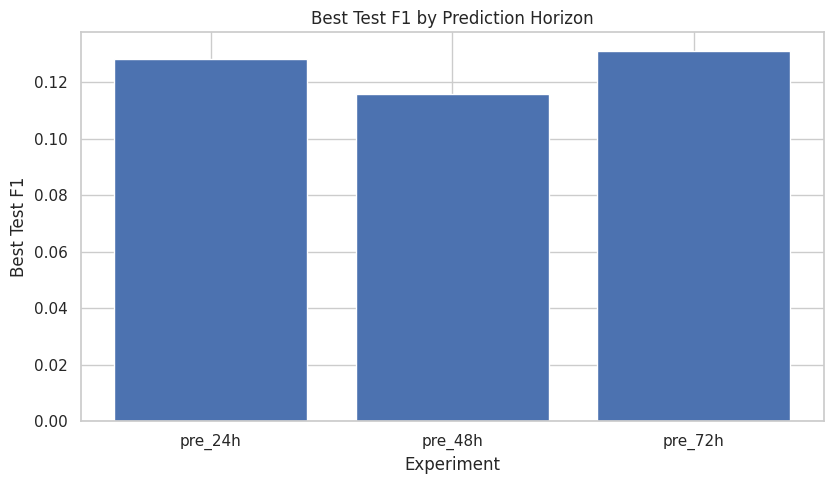

In [22]:
plot_df = horizon_comparison_df.sort_values("experiment_name").copy()

plt.figure(figsize=(8.5, 5))
plt.bar(plot_df["experiment_name"], plot_df["test_f1"])
plt.title("Best Test F1 by Prediction Horizon")
plt.xlabel("Experiment")
plt.ylabel("Best Test F1")
plt.tight_layout()
plt.show()


## Visualization 5 · Precision and recall by prediction horizon

Because the project is highly imbalanced, F1 alone is not enough. This plot shows the trade-off between precision and recall for the strongest model in each horizon experiment.


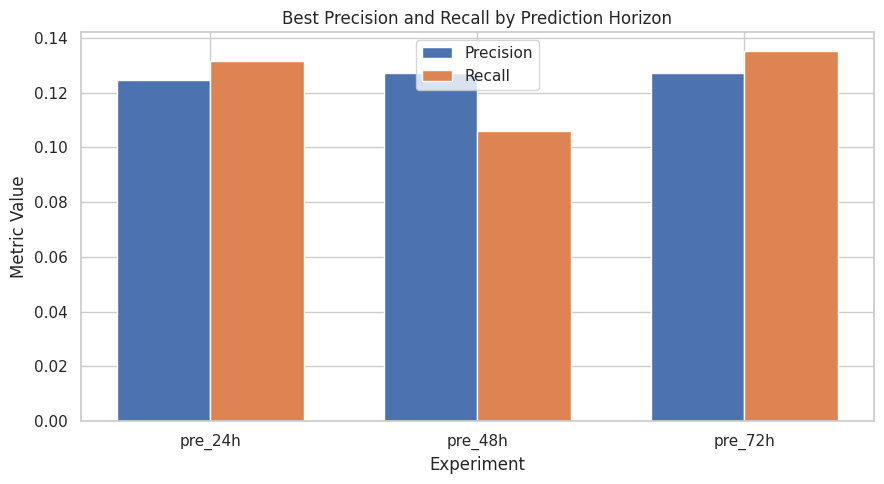

In [23]:
plot_df = horizon_comparison_df.sort_values("experiment_name").copy()
x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width / 2, plot_df["test_precision"], width=width, label="Precision")
plt.bar(x + width / 2, plot_df["test_recall"], width=width, label="Recall")
plt.xticks(x, plot_df["experiment_name"])
plt.title("Best Precision and Recall by Prediction Horizon")
plt.xlabel("Experiment")
plt.ylabel("Metric Value")
plt.legend()
plt.tight_layout()
plt.show()


## Select the strongest overall result for deeper diagnostics

The best experiment-model combination is selected from the horizon comparison table. This is the combination used for the feature importance and threshold-sweep diagnostics below.


In [24]:
best_overall_row = horizon_comparison_df.iloc[0].to_dict()
best_experiment_name = best_overall_row["experiment_name"]
best_bundle = experiment_bundles[best_experiment_name]

print("Best overall experiment:", best_experiment_name)
print("Best overall model:", best_overall_row.get("model_name"))
display(pd.DataFrame([best_overall_row]))


Best overall experiment: pre_72h
Best overall model: xgboost


,experiment_name,source,model_name,threshold,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_specificity
0,pre_72h,saved_artifact,xgboost,0.78,0.12712,0.135283,0.131075,0.438779,0.049057,0.551867,0.968451


## Visualization 6 · Feature importance for the strongest result

For tree-based models this shows feature importance; for logistic regression it shows coefficient magnitude. Either way, the plot identifies which engineered and operational signals contributed most to the final decision process.


,feature,importance
19,active_power,0.019096
18,gen_speed,0.019665
17,yaw_error,0.021586
16,pitch_angle,0.023216
15,yaw_error_volatility_24,0.024290
14,transformer_temp,0.027346
13,gearbox_oil_temp,0.031920
12,hub_temp,0.036645
11,generator_temp,0.038907
10,active_power_volatility_24,0.039414


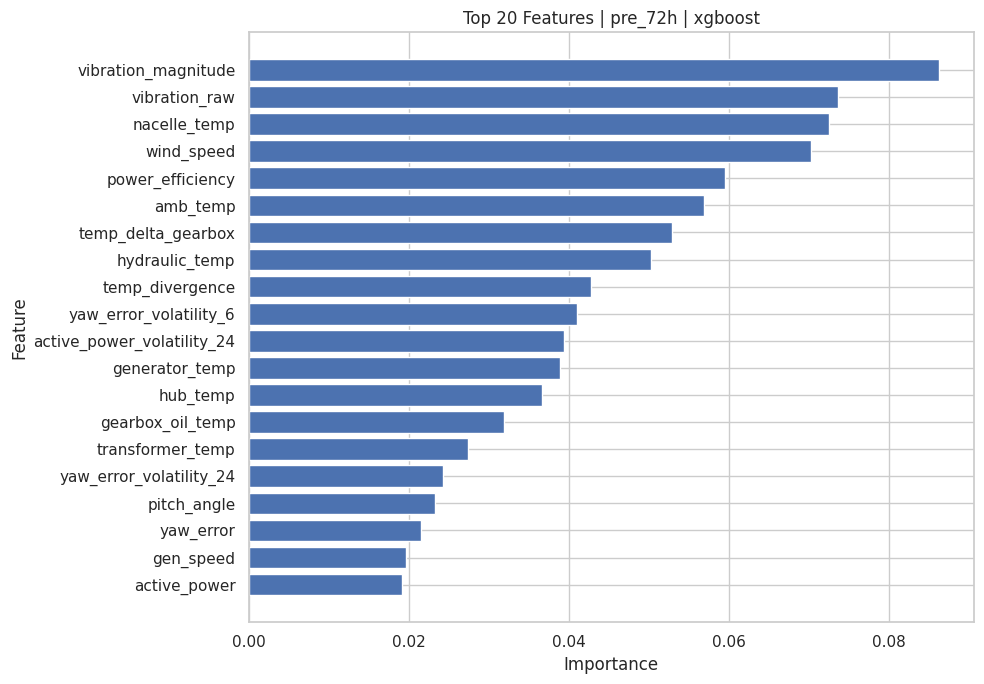

In [25]:
importance_df = best_bundle["importance_df"].copy()

value_col = "importance" if "importance" in importance_df.columns else "coefficient"
x_label = "Importance" if value_col == "importance" else "Coefficient"

plot_importance_df = (
    importance_df
    .sort_values(value_col, ascending=False)
    .head(TOP_N_FEATURES)
    .iloc[::-1]
)

display(plot_importance_df.tail(TOP_N_FEATURES))

plt.figure(figsize=(10, 7))
plt.barh(plot_importance_df["feature"], plot_importance_df[value_col])
plt.title(f"Top {TOP_N_FEATURES} Features | {best_experiment_name} | {best_overall_row.get('model_name')}")
plt.xlabel(x_label)
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Visualization 7 · Threshold sweep for the strongest result

The threshold sweep is important because the default probability cutoff is rarely optimal in imbalanced fault detection. This plot shows how precision, recall, and F1 change as the classification threshold moves.


,threshold,precision,recall,f1,balanced_accuracy,specificity,false_positive_rate,false_negative_rate,tp,fp,tn,fn,support_positive,support_negative,roc_auc,pr_auc
45,0.84,0.155036,0.115573,0.132427,0.547090,0.978607,0.021393,0.884427,3137,17097,782102,24006,27143,799199,0.438779,0.049057
44,0.82,0.142869,0.122831,0.132095,0.548902,0.974972,0.025028,0.877169,3334,20002,779197,23809,27143,799199,0.438779,0.049057
46,0.86,0.170815,0.107468,0.131931,0.544875,0.982282,0.017718,0.892532,2917,14160,785039,24226,27143,799199,0.438779,0.049057
43,0.80,0.133592,0.129315,0.131419,0.550416,0.971516,0.028484,0.870685,3510,22764,776435,23633,27143,799199,0.438779,0.049057
42,0.78,0.127120,0.135283,0.131075,0.551867,0.968451,0.031549,0.864717,3672,25214,773985,23471,27143,799199,0.438779,0.049057
41,0.76,0.120440,0.139999,0.129485,0.552638,0.965276,0.034724,0.860001,3800,27751,771448,23343,27143,799199,0.438779,0.049057
40,0.75,0.117465,0.142726,0.128869,0.553153,0.963581,0.036419,0.857274,3874,29106,770093,23269,27143,799199,0.438779,0.049057
39,0.74,0.114967,0.146115,0.128683,0.553957,0.961798,0.038202,0.853885,3966,30531,768668,23177,27143,799199,0.438779,0.049057
38,0.72,0.109387,0.150610,0.126730,0.554482,0.958353,0.041647,0.849390,4088,33284,765915,23055,27143,799199,0.438779,0.049057
47,0.88,0.184465,0.095015,0.125426,0.540374,0.985733,0.014267,0.904985,2579,11402,787797,24564,27143,799199,0.438779,0.049057


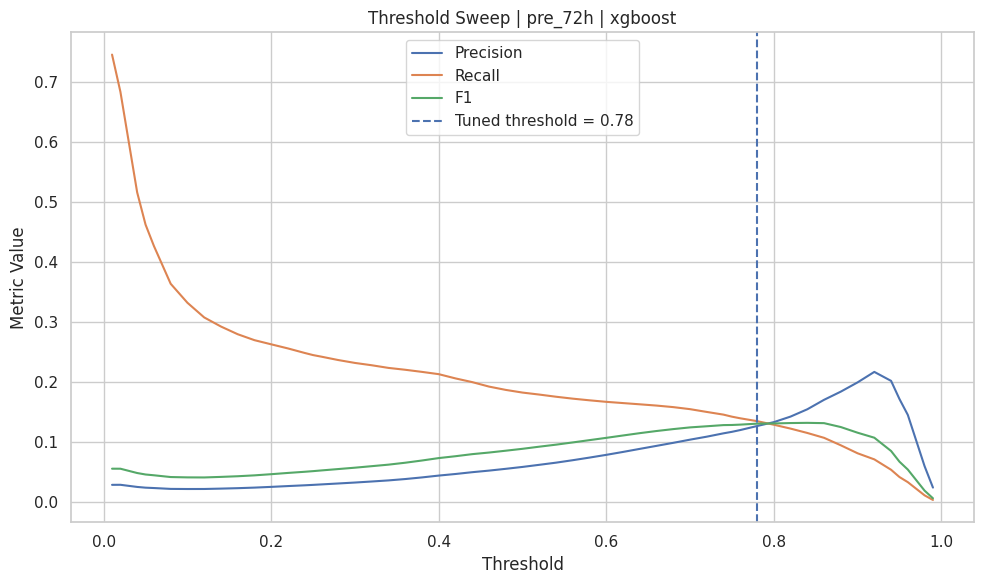

In [26]:
threshold_df = best_bundle["threshold_df"].copy()

display(
    threshold_df.sort_values(
        by=["f1", "recall", "precision"],
        ascending=[False, False, False],
    ).head(15)
)

tuned_threshold = best_bundle.get("best_threshold")

plt.figure(figsize=(10, 6))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
if tuned_threshold is not None:
    plt.axvline(tuned_threshold, linestyle="--", label=f"Tuned threshold = {tuned_threshold:.2f}")
plt.title(f"Threshold Sweep | {best_experiment_name} | {best_overall_row.get('model_name')}")
plt.xlabel("Threshold")
plt.ylabel("Metric Value")
plt.legend()
plt.tight_layout()
plt.show()


## Optional split diagnostics for fresh runs

When an experiment was executed directly in this notebook rather than loaded from saved artifacts, the next cell summarizes the train/validation/test sizes and positive rates. This helps verify that the chronological split behaved as expected.


In [27]:
if best_bundle["source"] == "fresh_run" and best_bundle["train_df"] is not None:
    split_sizes_df = pd.DataFrame(
        [
            {"split": "train", "rows": len(best_bundle["train_df"]), "positive_rate": best_bundle["train_df"]["target"].mean()},
            {"split": "val", "rows": len(best_bundle["val_df"]), "positive_rate": best_bundle["val_df"]["target"].mean()},
            {"split": "test", "rows": len(best_bundle["test_df"]), "positive_rate": best_bundle["test_df"]["target"].mean()},
        ]
    )
    display(split_sizes_df)
else:
    print("Split diagnostics were not available because this result came from saved artifacts.")


Split diagnostics were not available because this result came from saved artifacts.


## Final interpretation

This notebook demonstrates the full pipeline required by the assignment:

- **Data loading, cleaning, normalization, and preprocessing** are handled through the reusable `WindFarmProcessor`.
- **Exploratory inspection and visualization** are included to validate labels, missingness, and event behavior.
- **Methodology justification** is documented in markdown alongside the code.
- **Implementation** uses the modular `wtfd` package to avoid code duplication and reduce leakage risk.
- **Modeling and evaluation** compare multiple prediction windows and multiple algorithms using a consistent split strategy and threshold tuning workflow.

### Practical note
In a real project, these steps would remain split across multiple notebooks, scripts, and saved artifacts. For submission purposes, they are presented here in one reproducible notebook with artifact guards so the workflow stays manageable.


## Cleanup

The final cell releases large in-memory objects created for inspection. This is optional, but useful after a full run.


In [28]:
del sample_df
gc.collect()
print("Released sample inspection DataFrame from memory.")


Released sample inspection DataFrame from memory.
